# YOLOE + KG + CLIP — Fine-tune Hyperparameters

## Pipeline
1. Setup & Config
2. Load Dataset
3. Load KG
4. Evaluation
5. Prediction Utilities
6. KG+CLIP Method
7. Fine-tune: alpha → low_conf_thr → PRED_CONF

# Use KG and CLIP to improve recall for BDD100K is predicted by YOLOE

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.5 MB/s eta 0:00:0000:01


In [2]:
# 1. Installation and Imports
import json, copy
from pathlib import Path
from collections import Counter
from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yaml, numpy as np
from tqdm.auto import tqdm
from ultralytics import YOLO, YOLOE

import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torch.nn.functional as F

from transformers import CLIPProcessor, CLIPModel

print("All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All imports successful
PyTorch version: 2.10.0+cu128
CUDA available: True


In [7]:
# 2. Configuration
PATH_DATASET = Path("/kaggle/input/datasets/quckhnh123/bdd100k-subset")
PATH_KG = Path("/kaggle/input/datasets/quckhnh123/kg-ad-v3/KG.json")
IMAGE_DIR = PATH_DATASET / "images"
LABEL_DIR = PATH_DATASET / "labels"
DATA_YAML = PATH_DATASET / "data.yaml"

YOLOE_MODEL_PATH = "yoloe-26m-seg.pt"
YOLOWORLD_MODEL_PATH = "yolov8m-worldv2.pt"

DEVICE = 0
IMGSZ = 640
MAX_IMAGES_TEST = None        

PRED_CONF = 0.05               
EVAL_CONF_THR = 0.25          
IOU_THR = 0.50

USEFUL_RELATIONS = {"isa", "atlocation"}

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("Configuration loaded successfully")
print(f"  Dataset: {PATH_DATASET}")
print(f"  Images: {MAX_IMAGES_TEST or 'All'}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Configuration loaded successfully
  Dataset: /kaggle/input/datasets/quckhnh123/bdd100k-subset
  Images: All


In [4]:
# 3. Dataset Loading and Exploration
def load_classes_from_yaml(data_yaml_path):
    with open(data_yaml_path, "r") as f:
        data = yaml.safe_load(f)
    names = data["names"]
    if isinstance(names, dict):
        names = [names[k] for k in sorted(names.keys(), key=lambda x: int(x))]
    return [str(x) for x in names]

def load_image_paths(image_dir, max_images=None, seed=42):
    image_dir = Path(image_dir)
    image_paths = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        image_paths.extend(image_dir.glob(ext))
    return sorted(str(p) for p in image_paths)

def yolo_to_xyxy(xc, yc, bw, bh, w, h):
    x1 = (xc - bw/2) * w
    y1 = (yc - bh/2) * h
    x2 = (xc + bw/2) * w
    y2 = (yc + bh/2) * h
    return [float(x1), float(y1), float(x2), float(y2)]
    
def build_gt(image_paths, labels_dir, target_classes):
    gt = {}
    shapes = {}
    class_counts = Counter()
    for img_path in tqdm(image_paths, desc="Building Ground Truth"):
        try:
            with Image.open(img_path) as img:
                w, h = img.size 
        except Exception:
            continue
            
        shapes[img_path] = (w, h)
        label_path = Path(labels_dir) / (Path(img_path).stem + ".txt")
        boxes = []
        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(float(parts[0]))
                    if cls_id < 0 or cls_id >= len(target_classes):
                        continue
                    xc, yc, bw, bh = map(float, parts[1:5])
                    boxes.append({
                        "class_id": cls_id,
                        "class_name": target_classes[cls_id],
                        "bbox": yolo_to_xyxy(xc, yc, bw, bh, w, h)
                    })
                    class_counts[target_classes[cls_id]] += 1
        gt[img_path] = boxes
    return gt, shapes, class_counts

TARGET_CLASSES = load_classes_from_yaml(DATA_YAML)
image_paths = load_image_paths(IMAGE_DIR, max_images=MAX_IMAGES_TEST)
GT, IMAGE_SHAPES, CLASS_COUNTS = build_gt(image_paths, LABEL_DIR, TARGET_CLASSES)

print(f"\n Dataset Statistics:")
print(f"  - Total images: {len(image_paths)}")
print(f"  - Total annotations: {sum(len(v) for v in GT.values()):,}")
print(f"  - Classes: {len(TARGET_CLASSES)}")
print(f"  - Average objects per image: {sum(len(v) for v in GT.values())/len(GT):.2f}")

Building Ground Truth:   0%|          | 0/10000 [00:00<?, ?it/s]


 Dataset Statistics:
  - Total images: 10000
  - Total annotations: 190,888
  - Classes: 10
  - Average objects per image: 19.09


In [8]:
# 4. Load ConceptNet + build concept sets
def normalize_name(x):
    return str(x).lower().replace("_", " ").replace("-", " ").strip()

def clean_concept_uri(x):
    x = str(x).lower().strip()
    for w in ["a ", "an ", "the "]:
        x = x.replace(w, "")
    return normalize_name(x)

def clean_relation(x):
    m = {"AtLocation":"atlocation", "IsA":"isa"}
    return m.get(x, x.lower().strip())

def is_noisy_concept(text, max_words=5):
    t = normalize_name(text)
    return len(t)<=1 or '/' in t or len(t.split())>max_words

def load_conceptnet_json(path):
    with open(path, "r", encoding="utf-8") as f:
        kg = json.load(f)
    graph = {}
    total_triples = 0
    for cls, relations in kg.items():
        cls = normalize_name(cls)
        graph[cls] = {}
        for relation, objects in relations.items():
            relation = clean_relation(relation)
            if relation not in USEFUL_RELATIONS:
                continue
            concepts = { clean_concept_uri(obj) for obj in objects if not is_noisy_concept(obj) }
            graph[cls][relation] = concepts
            total_triples += len(concepts)

    print(f"Loaded {total_triples} triples from KG JSON")
    return graph

def build_class_concepts(target_classes, graph, top_k=30):
    class_concepts = {}

    for cls in target_classes:
        cls_clean = normalize_name(cls)
        relations = graph.get(cls_clean, {})

        class_concepts[cls] = {}

        for relation, concepts in relations.items():
            class_concepts[cls][relation] = set(list(concepts)[:top_k])
            
    return class_concepts

conceptnet_df = load_conceptnet_json(PATH_KG)
CLASS_CONCEPTS = build_class_concepts(TARGET_CLASSES, conceptnet_df, top_k=30)

print(f"\n Knowledge Graph Statistics:")
print(f"  Total triples: {len(conceptnet_df)}")
print(f"  Classes with concepts: {sum(1 for c in CLASS_CONCEPTS if CLASS_CONCEPTS[c])}")
for cls, concepts in CLASS_CONCEPTS.items():
    total_concepts_for_class = sum(len(concept_set) for concept_set in concepts.values())
    print(f"  {cls:15s}: {total_concepts_for_class} concepts")

Loaded 155 triples from KG JSON

 Knowledge Graph Statistics:
  Total triples: 24
  Classes with concepts: 10
  person         : 8 concepts
  rider          : 7 concepts
  car            : 13 concepts
  bus            : 9 concepts
  truck          : 7 concepts
  bike           : 5 concepts
  motor          : 4 concepts
  traffic light  : 5 concepts
  traffic sign   : 5 concepts
  train          : 3 concepts


In [9]:
# 5. Evaluation Functions
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter + 1e-9
    return inter / union

def compute_map_torchmetrics(preds_dict, gt_dict):
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    preds = []
    targets = []
    all_imgs = sorted(gt_dict.keys())

    for img_path in all_imgs:
        pred_boxes, pred_scores, pred_labels = [], [], []
        for p in preds_dict.get(img_path, []):
            pred_boxes.append(p["bbox"])
            pred_scores.append(p["conf"])
            pred_labels.append(p["class_id"])

        gt_boxes, gt_labels = [], []
        for g in gt_dict.get(img_path, []):
            gt_boxes.append(g["bbox"])
            gt_labels.append(g["class_id"])

        preds.append({
            "boxes": torch.tensor(pred_boxes, dtype=torch.float32).reshape(-1,4),
            "scores": torch.tensor(pred_scores, dtype=torch.float32),
            "labels": torch.tensor(pred_labels, dtype=torch.int64)
        })
        targets.append({
            "boxes": torch.tensor(gt_boxes, dtype=torch.float32).reshape(-1,4),
            "labels": torch.tensor(gt_labels, dtype=torch.int64)
        })

    metric.update(preds, targets)
    result = metric.compute()
    return {"map50": float(result["map_50"]), "map50_95": float(result["map"])}

def evaluate(preds_dict, gt_dict, target_classes, conf_thr=0.25, iou_thr=0.5):
    per_class = {c: {"tp":0,"fp":0,"fn":0} for c in target_classes}
    for img_path, gt_boxes in gt_dict.items():
        preds = [p for p in preds_dict.get(img_path, []) if p["conf"] >= conf_thr]
        preds = sorted(preds, key=lambda x: x["conf"], reverse=True)
        matched = set()
        for p in preds:
            best_iou, best_idx = 0.0, -1
            for i,g in enumerate(gt_boxes):
                if i in matched or p["class_id"] != g["class_id"]:
                    continue
                iou = compute_iou(p["bbox"], g["bbox"])
                if iou > best_iou:
                    best_iou, best_idx = iou, i
            if best_iou >= iou_thr and best_idx >= 0:
                per_class[p["class_name"]]["tp"] += 1
                matched.add(best_idx)
            else:
                per_class[p["class_name"]]["fp"] += 1
        for i,g in enumerate(gt_boxes):
            if i not in matched:
                per_class[g["class_name"]]["fn"] += 1

    rows, total_tp, total_fp, total_fn = [], 0, 0, 0
    for cls in target_classes:
        tp, fp, fn = per_class[cls]["tp"], per_class[cls]["fp"], per_class[cls]["fn"]
        p = tp/(tp+fp+1e-9)
        r = tp/(tp+fn+1e-9)
        f = 2*p*r/(p+r+1e-9)
        rows.append({"class_name":cls, "tp":tp, "fp":fp, "fn":fn, "precision":p, "recall":r, "f1":f})
        total_tp += tp; total_fp += fp; total_fn += fn

    p_all = total_tp/(total_tp+total_fp+1e-9)
    r_all = total_tp/(total_tp+total_fn+1e-9)
    f_all = 2*p_all*r_all/(p_all+r_all+1e-9)
    map_result = compute_map_torchmetrics(preds_dict, gt_dict)
    
    summary = {
        "precision": p_all, "recall": r_all, "f1": f_all,
        "map50": map_result["map50"], "map50_95": map_result["map50_95"],
        "total_tp": total_tp, "total_fp": total_fp, "total_fn": total_fn
    }
    return summary, pd.DataFrame(rows)

In [10]:
# 6. Prediction Utilities
def load_yoloe_with_prompts(path, target_classes):
    model = YOLOE(path)
    prompts = [c.replace("_", " ") for c in target_classes]
    model.set_classes(prompts)
    return model

def load_yoloworld(path, target_classes):
    model = YOLO(path)
    prompts = [c.replace("_", " ") for c in target_classes]
    model.set_classes(prompts)
    return model

def predict_model(model, image_paths, target_classes, conf=0.03, imgsz=640, device=0, an=True):
    all_preds = {} 
    for img in tqdm(image_paths, desc="Predicting"):
        results = model.predict(source=img, conf=conf, imgsz=imgsz, device=device, verbose=False, agnostic_nms=an)
        preds = []
        for r in results:
            if r.boxes is None:
                continue
            boxes = r.boxes.xyxy.cpu().numpy()
            scores = r.boxes.conf.cpu().numpy()
            clses = r.boxes.cls.cpu().numpy().astype(int)
            for box, score, cls_id in zip(boxes, scores, clses):
                if 0 <= cls_id < len(target_classes):
                    preds.append({
                        "image": img,
                        "class_id": int(cls_id),
                        "class_name": target_classes[cls_id],
                        "conf": float(score),
                        "bbox": [float(x) for x in box]
                    })
        all_preds[img] = preds
    return all_preds

In [11]:
pred_conf_list = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]

results = []

model_yoloe = load_yoloe_with_prompts(YOLOE_MODEL_PATH, TARGET_CLASSES)

for pred_conf in pred_conf_list:
    print(f"\n===== PRED_CONF = {pred_conf} =====")

    pred_yoloe = predict_model(
        model=model_yoloe,
        image_paths=image_paths,
        target_classes=TARGET_CLASSES,
        conf=pred_conf,
        imgsz=IMGSZ,
        device=DEVICE,
        an=False
    )

    summary, _ = evaluate(
        pred_yoloe,
        GT,
        TARGET_CLASSES,
        conf_thr=EVAL_CONF_THR,
        iou_thr=IOU_THR
    )

    summary["pred_conf"] = pred_conf
    results.append(summary)

requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 36 packages in 778ms
Prepared 2 packages in 2.01s
Installed 2 packages in 1ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@488e81a6711eea7346872b46ea928b367da8889d)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 3.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


===== PRED_CONF = 0.01 =====


Predicting:   0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)



===== PRED_CONF = 0.05 =====


Predicting:   0%|          | 0/10000 [00:00<?, ?it/s]

...

Predicting:   0%|          | 0/10000 [00:00<?, ?it/s]


===== PRED_CONF = 0.3 =====


Predicting:   0%|          | 0/10000 [00:00<?, ?it/s]


===== PRED_CONF = 0.4 =====


Predicting:   0%|          | 0/10000 [00:00<?, ?it/s]

,pred_conf,map50,map50_95,precision,recall,f1,total_tp,total_fp,total_fn
0,0.01,0.303366,0.169662,0.801732,0.229438,0.356775,43797,10831,147091
1,0.05,0.259571,0.151844,0.801732,0.229438,0.356775,43797,10831,147091
2,0.10,0.230989,0.138942,0.801732,0.229438,0.356775,43797,10831,147091
3,0.15,0.209574,0.129195,0.801732,0.229438,0.356775,43797,10831,147091
4,0.20,0.195120,0.121922,0.801732,0.229438,0.356775,43797,10831,147091
5,0.25,0.182199,0.115418,0.801732,0.229438,0.356775,43797,10831,147091
6,0.30,0.169930,0.109783,0.829689,0.206949,0.331269,39504,8109,151384
7,0.40,0.148834,0.098827,0.870229,0.169256,0.283394,32309,4818,158579


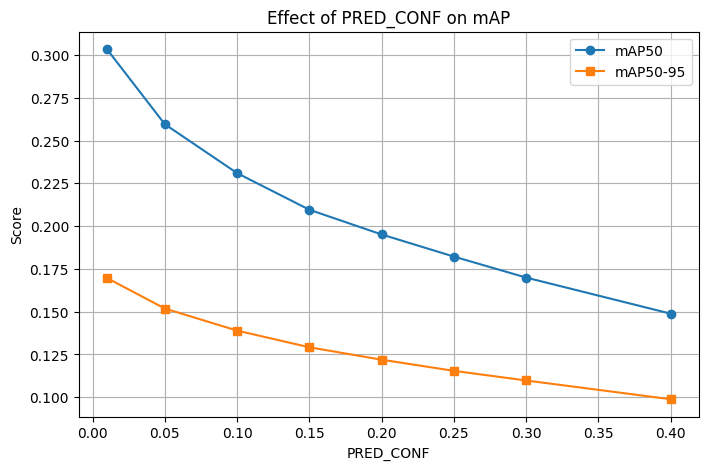

In [12]:
df = pd.DataFrame(results)

df = df[[
    "pred_conf",
    "map50",
    "map50_95",
    "precision",
    "recall",
    "f1",
    "total_tp",
    "total_fp",
    "total_fn"
]]

df = df.sort_values(
    ["map50_95", "map50", "f1"],
    ascending=False
)

display(df)

plt.figure(figsize=(8,5))

plt.plot(df["pred_conf"], df["map50"], marker="o", label="mAP50")
plt.plot(df["pred_conf"], df["map50_95"], marker="s", label="mAP50-95")

plt.xlabel("PRED_CONF")
plt.ylabel("Score")
plt.title("Effect of PRED_CONF on mAP")
plt.grid(True)
plt.legend()

plt.show()